# 04_feature_engineering_and_graph_construction.ipynb

## Σκοπός

Το notebook αυτό αποτελεί το **canonical validated-only feature engineering stage** της ενεργής forecasting pipeline για το **DaKS / Kassel wind dataset**.

Το `NB04`:

- διαβάζει το `MASTER_DATASET` που παρήχθη από το `NB03`
- σέβεται το **coverage-aware downstream contract** του `NB02`
- δημιουργεί **forecasting-ready temporal και autoregressive features**
- ενσωματώνει και ελέγχει τη **spatial metadata** που υπάρχει ήδη στο canonical downstream cohort
- κατασκευάζει **graph-ready spatial artifacts**
- εξάγει καθαρά downstream outputs για τα επόμενα notebooks

## Τι δεν κάνει

Το `NB04` **δεν** είναι:

- raw validation notebook
- raw cleaning notebook
- notebook για loose reparsing raw timestamps
- notebook για ad hoc rediscovery του `meta.csv`
- split notebook
- modeling notebook

## Methodological contract

Το ενεργό canonical progression του pipeline είναι:

`NB02 raw validation -> NB03 validated-only EDA -> NB04 feature engineering`

Άρα σε αυτό το στάδιο ισχύουν αυστηρά οι παρακάτω αρχές:

- το `NB02` παραμένει η **μοναδική canonical raw-validation authority**
- το `NB03` έχει ήδη παραδώσει canonical `MASTER_DATASET`
- το `NB04` **δεν** ξανακάνει loose `pd.to_datetime(..., format="mixed")`
- το `NB04` χρησιμοποιεί μόνο το **strict downstream cohort** με `nb04_eligible == True`
- οι lag / rolling features πρέπει να είναι **causal** και **leakage-safe**
- το spatial graph αντιμετωπίζεται ως **graph-ready engineering artifact** και όχι ως ήδη υλοποιημένο GNN stage

In [1]:
# --------------------------------------------------------------
# NB04 | Imports, paths και plotting defaults
# --------------------------------------------------------------

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Κριτήριο:
    - ύπαρξη φακέλου data/
    - ύπαρξη φακέλου notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε το project root με φακέλους 'data/' και 'notebooks/'."
    )


ROOT = find_project_root(Path.cwd())

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))


from src.config import (
    MASTER_DATASET,
    MASTER_PARK_SUMMARY,
    NB02_META_COVERAGE_AUDIT,
    FINAL_DATASET,
    ADJACENCY_MATRIX,
    TARGET_COLUMN,
    BASELINE_COLUMN,
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    RANDOM_SEED,
)

# Plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("Project root:", ROOT)
print("MASTER_DATASET:", MASTER_DATASET)
print("NB02 coverage-aware audit:", NB02_META_COVERAGE_AUDIT)
print("FINAL_DATASET:", FINAL_DATASET)
print("ADJACENCY_MATRIX:", ADJACENCY_MATRIX)
print("RANDOM_SEED:", RANDOM_SEED)

Project root: C:\Users\diony\Desktop\WindPower_DigitalTwin
MASTER_DATASET: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_dataset.csv
NB02 coverage-aware audit: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb02_meta_coverage_audit.csv
FINAL_DATASET: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\final_feature_engineered_dataset.csv
ADJACENCY_MATRIX: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\adjacency_matrix.npy
RANDOM_SEED: 42


## Upstream contract και αυστηρές αρχές

Το `NB04` στηρίζεται αποκλειστικά σε **validated downstream artifacts**.

### Επιτρεπτό input layer
- `MASTER_DATASET`
- `NB02_META_COVERAGE_AUDIT`
- προαιρετικά park-level summaries από το `NB03` για consistency checks

### Ρητά απαγορευμένες πρακτικές σε αυτό το στάδιο
- loose reparsing raw timestamps
- raw separator rediscovery
- ad hoc scanning των raw CSV folders
- implicit redefinition του downstream cohort
- rolling statistics που περιέχουν την τρέχουσα τιμή του target

### Βασική πρακτική για leakage-safe autoregressive features
Για κάθε park:

1. γίνεται αυστηρό sort κατά `park_id`, `timestamp`
2. τα **lags** κατασκευάζονται με `shift`
3. τα **rolling** κατασκευάζονται πάνω σε **shifted** series, ώστε η γραμμή `t` να μη "βλέπει" την τιμή του target στη στιγμή `t`

Με άλλα λόγια, το `NB04` πρέπει να είναι **causal-by-construction**.

In [2]:
# --------------------------------------------------------------
# NB04 | Load canonical downstream artifacts
# --------------------------------------------------------------

required_paths = [
    MASTER_DATASET,
    NB02_META_COVERAGE_AUDIT,
]

for path in required_paths:
    if not Path(path).exists():
        raise FileNotFoundError(f"Λείπει required upstream artifact: {path}")

master_df = pd.read_csv(
    MASTER_DATASET,
    dtype={
        PARK_ID_COLUMN: "string",
        "fcst_time": "string",
        "time": "string",
        "turbine": "string",
        "loader_input_sep_used": "string",
        "loader_target_sep_used": "string",
        "loader_input_ts_format": "string",
        "loader_target_ts_format": "string",
    }
)

coverage_audit_df = pd.read_csv(
    NB02_META_COVERAGE_AUDIT,
    dtype={
        "park_id": "string",
        "status": "string",
        "coverage_class": "string",
    }
)

if MASTER_PARK_SUMMARY.exists():
    park_summary_upstream_df = pd.read_csv(
        MASTER_PARK_SUMMARY,
        dtype={"park_id": "string", "coverage_class": "string"}
    )
else:
    park_summary_upstream_df = None

# --------------------------------------------------------------
# Canonical type normalization
# --------------------------------------------------------------
master_df[PARK_ID_COLUMN] = master_df[PARK_ID_COLUMN].astype("string").str.zfill(5)
coverage_audit_df["park_id"] = coverage_audit_df["park_id"].astype("string").str.zfill(5)

# Το timestamp backbone επιτρέπεται να γίνει parse μόνο από το canonical
# downstream artifact και μόνο με explicit format.
master_df[TIMESTAMP_COLUMN] = pd.to_datetime(
    master_df[TIMESTAMP_COLUMN],
    format="%Y-%m-%d %H:%M:%S",
    errors="raise",
)

# --------------------------------------------------------------
# Strict downstream cohort check
# --------------------------------------------------------------
eligible_parks = sorted(
    coverage_audit_df.loc[
        coverage_audit_df["nb04_eligible"] == True, "park_id"
    ].dropna().unique().tolist()
)

observed_master_parks = sorted(master_df[PARK_ID_COLUMN].dropna().unique().tolist())

unexpected_in_master = sorted(set(observed_master_parks) - set(eligible_parks))
missing_from_master = sorted(set(eligible_parks) - set(observed_master_parks))

if unexpected_in_master:
    raise ValueError(
        "Βρέθηκαν parks στο MASTER_DATASET που δεν είναι NB04-eligible: "
        f"{unexpected_in_master[:10]}"
    )

if missing_from_master:
    raise ValueError(
        "Λείπουν NB04-eligible parks από το MASTER_DATASET: "
        f"{missing_from_master[:10]}"
    )

# --------------------------------------------------------------
# Core integrity checks
# --------------------------------------------------------------
required_core_columns = [
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    TARGET_COLUMN,
    "lat",
    "long",
    "Wind_Speed_100m_ms",
    "ws_ref",
]

missing_core_columns = [col for col in required_core_columns if col not in master_df.columns]
if missing_core_columns:
    raise KeyError(f"Λείπουν required core columns: {missing_core_columns}")

if master_df[TIMESTAMP_COLUMN].isna().any():
    nat_count = int(master_df[TIMESTAMP_COLUMN].isna().sum())
    raise ValueError(f"Βρέθηκαν NaT timestamps στο MASTER_DATASET ({nat_count}).")

duplicate_count = int(
    master_df.duplicated(subset=[PARK_ID_COLUMN, TIMESTAMP_COLUMN]).sum()
)
if duplicate_count > 0:
    raise ValueError(
        f"Βρέθηκαν duplicate (park_id, timestamp) rows στο MASTER_DATASET ({duplicate_count})."
    )

master_df = master_df.sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN]).reset_index(drop=True)

non_monotonic_parks = []
for park_id, park_slice in master_df.groupby(PARK_ID_COLUMN, sort=False):
    if not park_slice[TIMESTAMP_COLUMN].is_monotonic_increasing:
        non_monotonic_parks.append(park_id)

if non_monotonic_parks:
    raise ValueError(
        "Βρέθηκαν parks με μη monotonic canonical timestamp backbone: "
        f"{non_monotonic_parks[:10]}"
    )

print("MASTER_DATASET loaded successfully")
print("-" * 60)
print(f"Rows      : {len(master_df):,}")
print(f"Parks     : {master_df[PARK_ID_COLUMN].nunique():,}")
print(f"Min time  : {master_df[TIMESTAMP_COLUMN].min()}")
print(f"Max time  : {master_df[TIMESTAMP_COLUMN].max()}")
print(f"Columns   : {len(master_df.columns):,}")

MASTER_DATASET loaded successfully
------------------------------------------------------------
Rows      : 3,253,606
Parks     : 256
Min time  : 2018-12-08 00:00:00
Max time  : 2020-06-01 23:00:00
Columns   : 40


In [3]:
# --------------------------------------------------------------
# NB04 | Helper functions
# --------------------------------------------------------------

def resolve_first_available_column(
    columns: pd.Index,
    candidates: list[str],
    purpose: str,
) -> str:
    """
    Επιστρέφει την πρώτη διαθέσιμη στήλη από λίστα candidates.
    """
    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise KeyError(
        f"Δεν βρέθηκε κατάλληλη στήλη για {purpose}. "
        f"Tried candidates={candidates}"
    )


def add_cyclical_encoding(
    df: pd.DataFrame,
    source_col: str,
    period: int,
    prefix: str | None = None,
) -> pd.DataFrame:
    """
    Προσθέτει cyclical encoding (sin/cos) για διακριτή περιοδική μεταβλητή.
    """
    out = df.copy()
    base_name = prefix if prefix is not None else source_col

    out[f"{base_name}_sin"] = np.sin(2 * np.pi * out[source_col] / period)
    out[f"{base_name}_cos"] = np.cos(2 * np.pi * out[source_col] / period)

    return out


def causal_group_rolling(
    series: pd.Series,
    group_keys: pd.Series,
    window: int,
    stat: str,
    min_periods: int | None = None,
) -> pd.Series:
    """
    Υπολογίζει causal rolling statistic πάνω σε SHIFTED series.

    Κρίσιμη αρχή:
    - πρώτα shift(1)
    - μετά rolling(window)
    ώστε η γραμμή t να μη χρησιμοποιεί την τιμή t.
    """
    if min_periods is None:
        min_periods = window

    shifted = series.groupby(group_keys, sort=False).shift(1)

    rolled = (
        shifted.groupby(group_keys, sort=False)
        .rolling(window=window, min_periods=min_periods)
    )

    if stat == "mean":
        out = rolled.mean()
    elif stat == "std":
        out = rolled.std()
    else:
        raise ValueError(f"Unsupported rolling stat: {stat}")

    return out.reset_index(level=0, drop=True)


def haversine_distance_matrix_km(lat_deg: np.ndarray, lon_deg: np.ndarray) -> np.ndarray:
    """
    Υπολογίζει πλήρη haversine distance matrix σε km.
    """
    earth_radius_km = 6371.0088

    lat_rad = np.radians(lat_deg).reshape(-1, 1)
    lon_rad = np.radians(lon_deg).reshape(-1, 1)

    dlat = lat_rad - lat_rad.T
    dlon = lon_rad - lon_rad.T

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat_rad) * np.cos(lat_rad.T) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))

    return earth_radius_km * c


def build_binary_spatial_adjacency(
    coords_df: pd.DataFrame,
    distance_threshold_km: float,
    include_self_loops: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Χτίζει συμμετρικό binary adjacency matrix από park coordinates.

    Επιστρέφει:
    - adjacency_matrix
    - distance_matrix_km
    """
    if distance_threshold_km <= 0:
        raise ValueError("Το distance_threshold_km πρέπει να είναι θετικό.")

    required_cols = ["park_id", "lat", "long"]
    missing = [col for col in required_cols if col not in coords_df.columns]
    if missing:
        raise KeyError(f"Λείπουν required coordinate columns: {missing}")

    if coords_df["park_id"].duplicated().any():
        raise ValueError("Βρέθηκαν duplicate park_ids στο coordinate dataframe.")

    if coords_df[["lat", "long"]].isna().any().any():
        raise ValueError("Βρέθηκαν missing coordinate values στο coordinate dataframe.")

    distance_matrix_km = haversine_distance_matrix_km(
        coords_df["lat"].to_numpy(dtype=float),
        coords_df["long"].to_numpy(dtype=float),
    )

    adjacency_matrix = (distance_matrix_km <= distance_threshold_km).astype(np.uint8)

    if not include_self_loops:
        np.fill_diagonal(adjacency_matrix, 0)
    else:
        np.fill_diagonal(adjacency_matrix, 1)

    return adjacency_matrix, distance_matrix_km


TARGET_COL = resolve_first_available_column(
    master_df.columns,
    candidates=[TARGET_COLUMN, "pw"],
    purpose="target variable",
)

WIND_COL = resolve_first_available_column(
    master_df.columns,
    candidates=["Wind_Speed_100m_ms", "ws_ref"],
    purpose="engineered wind feature",
)

BASELINE_COL = resolve_first_available_column(
    master_df.columns,
    candidates=[BASELINE_COLUMN, "icon_eu_daf_pc_baseline"],
    purpose="baseline forecast column",
)

print("Resolved columns")
print("-" * 60)
print("TARGET_COL  :", TARGET_COL)
print("WIND_COL    :", WIND_COL)
print("BASELINE_COL:", BASELINE_COL)

Resolved columns
------------------------------------------------------------
TARGET_COL  : Power_Output_Normalized
WIND_COL    : Wind_Speed_100m_ms
BASELINE_COL: Baseline_Prediction


## Κατασκευή feature space

Το τελικό feature space του `NB04` χωρίζεται λογικά σε τέσσερα επίπεδα:

1. **Backbone / control columns**
   - `park_id`
   - `timestamp`
   - `test_flag`

2. **Static / spatial metadata**
   - `lat`, `long`
   - `hub_height_m`, `rotor_diameter_m`, `nominal_power_kW`
   - προαιρετικά `turbine` ως categorical metadata

3. **Exogenous meteorological / forecast features**
   - οι canonical NWP μεταβλητές
   - `ws_ref`
   - `Wind_Speed_100m_ms`
   - `Baseline_Prediction` ως auxiliary reference column

4. **Engineered causal features**
   - cyclical time encodings
   - target lags
   - wind lags
   - causal rolling statistics

### Σημαντική επιλογή σχεδιασμού

Columns που ανήκουν καθαρά σε **audit / provenance layer** και όχι σε πραγματικό forecasting feature space
δεν πρέπει να περνούν στο τελικό exported dataset ως candidate model inputs.

Για τον λόγο αυτό, provenance columns όπως raw separator diagnostics, timestamp format diagnostics
και sample-count bookkeeping απομακρύνονται από το τελικό canonical export.

In [4]:
# --------------------------------------------------------------
# NB04 | Temporal feature engineering
# --------------------------------------------------------------

df_fe = master_df.copy()

# Backbone-derived calendar components
df_fe["hour"] = df_fe[TIMESTAMP_COLUMN].dt.hour
df_fe["month"] = df_fe[TIMESTAMP_COLUMN].dt.month

# Κυκλικές κωδικοποιήσεις
df_fe = add_cyclical_encoding(df_fe, source_col="hour", period=24, prefix="hour")
df_fe = add_cyclical_encoding(df_fe, source_col="month", period=12, prefix="month")

# --------------------------------------------------------------
# Autoregressive lag features (causal και ανά park)
# --------------------------------------------------------------
lag_steps = [1, 3, 6]

for lag in lag_steps:
    df_fe[f"{TARGET_COL}_lag_{lag}"] = (
        df_fe.groupby(PARK_ID_COLUMN, sort=False)[TARGET_COL].shift(lag)
    )
    df_fe[f"{WIND_COL}_lag_{lag}"] = (
        df_fe.groupby(PARK_ID_COLUMN, sort=False)[WIND_COL].shift(lag)
    )

# --------------------------------------------------------------
# Causal rolling features
# --------------------------------------------------------------
rolling_window = 6

df_fe["power_rolling_mean_6h"] = causal_group_rolling(
    series=df_fe[TARGET_COL],
    group_keys=df_fe[PARK_ID_COLUMN],
    window=rolling_window,
    stat="mean",
    min_periods=rolling_window,
)

df_fe["power_rolling_std_6h"] = causal_group_rolling(
    series=df_fe[TARGET_COL],
    group_keys=df_fe[PARK_ID_COLUMN],
    window=rolling_window,
    stat="std",
    min_periods=rolling_window,
)

df_fe["wind_rolling_mean_6h"] = causal_group_rolling(
    series=df_fe[WIND_COL],
    group_keys=df_fe[PARK_ID_COLUMN],
    window=rolling_window,
    stat="mean",
    min_periods=rolling_window,
)

df_fe["wind_rolling_std_6h"] = causal_group_rolling(
    series=df_fe[WIND_COL],
    group_keys=df_fe[PARK_ID_COLUMN],
    window=rolling_window,
    stat="std",
    min_periods=rolling_window,
)

engineered_cols = [
    "hour",
    "month",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    *[f"{TARGET_COL}_lag_{lag}" for lag in lag_steps],
    *[f"{WIND_COL}_lag_{lag}" for lag in lag_steps],
    "power_rolling_mean_6h",
    "power_rolling_std_6h",
    "wind_rolling_mean_6h",
    "wind_rolling_std_6h",
]

print("Engineered columns")
print("-" * 60)
print(engineered_cols)

display(
    df_fe[
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, TARGET_COL, WIND_COL, "hour_sin", "hour_cos"]
    ].head()
)

Engineered columns
------------------------------------------------------------
['hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Power_Output_Normalized_lag_1', 'Power_Output_Normalized_lag_3', 'Power_Output_Normalized_lag_6', 'Wind_Speed_100m_ms_lag_1', 'Wind_Speed_100m_ms_lag_3', 'Wind_Speed_100m_ms_lag_6', 'power_rolling_mean_6h', 'power_rolling_std_6h', 'wind_rolling_mean_6h', 'wind_rolling_std_6h']


,park_id,timestamp,Power_Output_Normalized,Wind_Speed_100m_ms,hour_sin,hour_cos
0,00011,2018-12-08 00:00:00,0.100,12.191844,0.000000,1.000000
1,00011,2018-12-08 01:00:00,0.126,13.298313,0.258819,0.965926
2,00011,2018-12-08 02:00:00,0.232,12.476142,0.500000,0.866025
3,00011,2018-12-08 03:00:00,0.248,13.399685,0.707107,0.707107
4,00011,2018-12-08 04:00:00,0.232,14.026279,0.866025,0.500000


In [5]:
# --------------------------------------------------------------
# NB04 | Post-engineering row filtering και feature-space curation
# --------------------------------------------------------------

rows_before = len(df_fe)
parks_before = df_fe[PARK_ID_COLUMN].nunique()

# Κρατάμε μόνο γραμμές όπου οι engineered causal features είναι διαθέσιμες.
df_fe = df_fe.dropna(subset=engineered_cols).reset_index(drop=True)

rows_after = len(df_fe)
parks_after = df_fe[PARK_ID_COLUMN].nunique()

if parks_after != parks_before:
    raise ValueError(
        "Η κατασκευή engineered features άλλαξε το πλήθος των parks. "
        f"Before={parks_before}, After={parks_after}"
    )

# --------------------------------------------------------------
# Columns that belong to provenance / audit layer
# --------------------------------------------------------------
provenance_cols_to_drop = [
    "fcst_time",
    "time",
    "loader_input_sep_used",
    "loader_target_sep_used",
    "loader_input_ts_format",
    "loader_target_ts_format",
    "loader_scaled_input_by_1000",
    "num_train_samples",
    "num_test_samples",
]

provenance_cols_to_drop = [col for col in provenance_cols_to_drop if col in df_fe.columns]

# Δεν αφαιρούμε backbone / control columns όπως:
# - park_id
# - timestamp
# - test_flag
# ούτε useful static metadata όπως:
# - lat, long, hub_height_m, rotor_diameter_m, nominal_power_kW
# Το Baseline_Prediction παραμένει ως auxiliary reference column και όχι
# ως υποχρεωτικό modeling input.
df_final = df_fe.drop(columns=provenance_cols_to_drop).copy()

# --------------------------------------------------------------
# Reorder columns για καθαρό export
# --------------------------------------------------------------
backbone_cols = [
    col for col in [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "test_flag"] if col in df_final.columns
]

target_cols = [col for col in [TARGET_COL, BASELINE_COL] if col in df_final.columns]

static_cols = [
    col for col in [
        "turbine",
        "hub_height_m",
        "rotor_diameter_m",
        "nominal_power_kW",
        "lat",
        "long",
    ]
    if col in df_final.columns
]

engineered_cols_present = [col for col in engineered_cols if col in df_final.columns]

remaining_cols = [
    col for col in df_final.columns
    if col not in set(backbone_cols + target_cols + static_cols + engineered_cols_present)
]

ordered_cols = backbone_cols + target_cols + static_cols + remaining_cols + engineered_cols_present
df_final = df_final.loc[:, ordered_cols].copy()

# --------------------------------------------------------------
# Final integrity checks
# --------------------------------------------------------------
final_duplicate_count = int(
    df_final.duplicated(subset=[PARK_ID_COLUMN, TIMESTAMP_COLUMN]).sum()
)
if final_duplicate_count > 0:
    raise ValueError(
        "Βρέθηκαν duplicate (park_id, timestamp) rows μετά το feature engineering "
        f"({final_duplicate_count})."
    )

final_non_monotonic_parks = []
for park_id, park_slice in df_final.groupby(PARK_ID_COLUMN, sort=False):
    if not park_slice[TIMESTAMP_COLUMN].is_monotonic_increasing:
        final_non_monotonic_parks.append(park_id)

if final_non_monotonic_parks:
    raise ValueError(
        "Βρέθηκαν parks με μη monotonic backbone μετά το feature engineering: "
        f"{final_non_monotonic_parks[:10]}"
    )

print("Feature engineering completed successfully")
print("-" * 60)
print(f"Rows before dropna(engineered subset): {rows_before:,}")
print(f"Rows after  dropna(engineered subset): {rows_after:,}")
print(f"Rows removed                        : {rows_before - rows_after:,}")
print(f"Parks retained                      : {parks_after:,}")
print(f"Columns retained in final dataset   : {len(df_final.columns):,}")

feature_catalog_df = pd.DataFrame(
    {
        "column": df_final.columns,
        "is_engineered": [col in engineered_cols_present for col in df_final.columns],
        "dtype": [str(dtype) for dtype in df_final.dtypes],
    }
)

display(feature_catalog_df.head(20))
display(df_final.head())

Feature engineering completed successfully
------------------------------------------------------------
Rows before dropna(engineered subset): 3,253,606
Rows after  dropna(engineered subset): 3,252,070
Rows removed                        : 1,536
Parks retained                      : 256
Columns retained in final dataset   : 47


,column,is_engineered,dtype
0,park_id,False,string
1,timestamp,False,datetime64[us]
2,test_flag,False,int64
3,Power_Output_Normalized,False,float64
4,Baseline_Prediction,False,float64
5,turbine,False,string
6,hub_height_m,False,int64
7,rotor_diameter_m,False,float64
8,nominal_power_kW,False,float64
9,lat,False,float64


,park_id,timestamp,test_flag,Power_Output_Normalized,Baseline_Prediction,turbine,hub_height_m,rotor_diameter_m,nominal_power_kW,lat,...,Power_Output_Normalized_lag_1,Power_Output_Normalized_lag_3,Power_Output_Normalized_lag_6,Wind_Speed_100m_ms_lag_1,Wind_Speed_100m_ms_lag_3,Wind_Speed_100m_ms_lag_6,power_rolling_mean_6h,power_rolling_std_6h,wind_rolling_mean_6h,wind_rolling_std_6h
0,00011,2018-12-08 06:00:00,0,0.134,0.790,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,...,0.265,0.248,0.100,12.342724,13.399685,12.191844,0.200500,0.069356,12.955831,0.727989
1,00011,2018-12-08 07:00:00,0,0.117,0.694,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,...,0.134,0.232,0.126,12.053271,14.026279,13.298313,0.206167,0.060301,12.932736,0.758627
2,00011,2018-12-08 08:00:00,0,0.330,0.605,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,...,0.117,0.265,0.232,11.243089,12.342724,12.476142,0.204667,0.062756,12.590198,0.989428
3,00011,2018-12-08 09:00:00,0,0.314,0.759,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,...,0.330,0.134,0.248,10.625930,12.053271,13.399685,0.221000,0.081304,12.281830,1.278252
4,00011,2018-12-08 10:00:00,0,0.367,0.790,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,...,0.314,0.117,0.232,11.788309,11.243089,14.026279,0.232000,0.089717,12.013267,1.160245


## Spatial metadata integration και graph-ready construction

Σε αυτό το notebook **δεν** ξαναγίνεται raw metadata hunting.

Η spatial πληροφορία θεωρείται ήδη μέρος του canonical downstream cohort μέσω του `MASTER_DATASET`.
Άρα εδώ κάνουμε μόνο:

- strict validation ότι κάθε `park_id` έχει μοναδικές coordinate values
- deterministic node ordering
- distance-based graph construction με explicit threshold
- export graph artifacts σε μορφή κατάλληλη για downstream GNN preparation

### Design choices
- χρησιμοποιούμε **haversine distance** σε km αντί για Euclidean distance σε degrees
- ο exported adjacency matrix είναι **συμμετρικός**, **binary** και **χωρίς self-loops**
- η node order αποθηκεύεται ξεχωριστά ώστε τα μελλοντικά notebooks να μη βασίζονται σε implicit assumptions

In [6]:
# --------------------------------------------------------------
# NB04 | Spatial consistency checks
# --------------------------------------------------------------

park_coord_df = (
    df_final[[PARK_ID_COLUMN, "lat", "long"]]
    .drop_duplicates()
    .sort_values(PARK_ID_COLUMN)
    .reset_index(drop=True)
)

coord_dup_count = int(park_coord_df[PARK_ID_COLUMN].duplicated().sum())
if coord_dup_count > 0:
    raise ValueError(
        f"Βρέθηκαν duplicate park_ids στο park_coord_df ({coord_dup_count})."
    )

coord_per_park_counts = (
    df_final.groupby(PARK_ID_COLUMN)[["lat", "long"]]
    .nunique(dropna=False)
    .reset_index()
)

multi_coord_parks = coord_per_park_counts.loc[
    (coord_per_park_counts["lat"] > 1) | (coord_per_park_counts["long"] > 1),
    PARK_ID_COLUMN
].tolist()

if multi_coord_parks:
    raise ValueError(
        "Βρέθηκαν parks με μη μοναδικές coordinates μέσα στο final dataset: "
        f"{multi_coord_parks[:10]}"
    )

missing_coord_rows = int(park_coord_df[["lat", "long"]].isna().any(axis=1).sum())
if missing_coord_rows > 0:
    raise ValueError(
        f"Βρέθηκαν parks με missing coordinates ({missing_coord_rows})."
    )

print("Spatial consistency checks passed")
print("-" * 60)
print(f"Node count: {len(park_coord_df):,}")
display(park_coord_df.head())

Spatial consistency checks passed
------------------------------------------------------------
Node count: 256


,park_id,lat,long
0,00011,48.0000,8.5000
1,00090,50.7500,9.2500
2,00161,50.4375,7.4375
3,00164,53.0625,14.0000
4,00183,54.6875,13.4375


In [7]:
# --------------------------------------------------------------
# NB04 | Build graph-ready spatial artifacts
# --------------------------------------------------------------

GRAPH_DISTANCE_THRESHOLD_KM = 50.0
INCLUDE_SELF_LOOPS = False

adj_matrix, dist_matrix_km = build_binary_spatial_adjacency(
    coords_df=park_coord_df.rename(columns={PARK_ID_COLUMN: "park_id"}),
    distance_threshold_km=GRAPH_DISTANCE_THRESHOLD_KM,
    include_self_loops=INCLUDE_SELF_LOOPS,
)

# --------------------------------------------------------------
# Deterministic alignment checks
# --------------------------------------------------------------
graph_node_order = park_coord_df[PARK_ID_COLUMN].tolist()
data_node_order = (
    df_final[PARK_ID_COLUMN]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

if graph_node_order != data_node_order:
    raise ValueError(
        "Αποτυχία node alignment μεταξύ graph order και dataframe order."
    )

if adj_matrix.shape[0] != len(graph_node_order):
    raise ValueError(
        "Το adjacency matrix shape δεν συμφωνεί με το node count."
    )

if not np.array_equal(adj_matrix, adj_matrix.T):
    raise ValueError("Ο adjacency matrix δεν είναι συμμετρικός.")

if np.unique(adj_matrix).tolist() not in ([0], [0, 1], [1]):
    raise ValueError("Ο adjacency matrix δεν είναι binary.")

expected_diag_value = 1 if INCLUDE_SELF_LOOPS else 0
if not np.all(np.diag(adj_matrix) == expected_diag_value):
    raise ValueError("Η diagonal του adjacency matrix δεν συμφωνεί με το self-loop policy.")

degree_vector = adj_matrix.sum(axis=1)
edge_count_undirected = int(np.triu(adj_matrix, k=1).sum())
possible_edges = len(graph_node_order) * (len(graph_node_order) - 1) / 2
graph_density = edge_count_undirected / possible_edges if possible_edges > 0 else 0.0

print("Graph construction completed successfully")
print("-" * 60)
print(f"Nodes                 : {len(graph_node_order):,}")
print(f"Edges (undirected)    : {edge_count_undirected:,}")
print(f"Graph density         : {graph_density:.6f}")
print(f"Mean degree           : {degree_vector.mean():.3f}")
print(f"Median degree         : {np.median(degree_vector):.3f}")
print(f"Min / Max degree      : {degree_vector.min():.0f} / {degree_vector.max():.0f}")
print(f"Distance threshold km : {GRAPH_DISTANCE_THRESHOLD_KM:.1f}")

Graph construction completed successfully
------------------------------------------------------------
Nodes                 : 256
Edges (undirected)    : 534
Graph density         : 0.016360
Mean degree           : 4.172
Median degree         : 4.000
Min / Max degree      : 1 / 8
Distance threshold km : 50.0


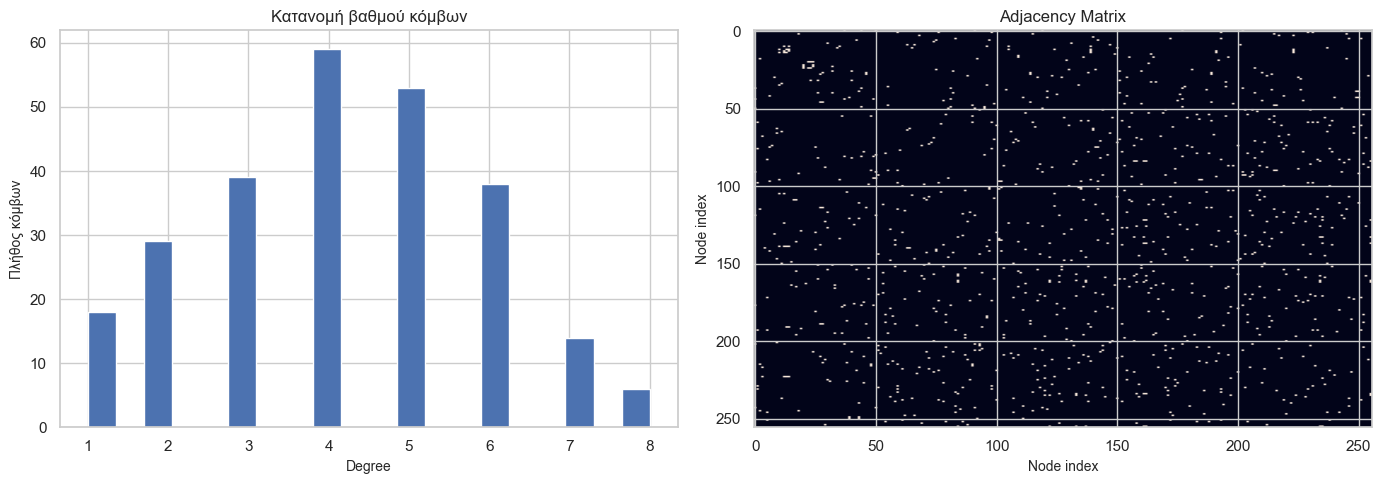

,metric,value
0,nodes,256.000000
1,edges_undirected,534.000000
2,graph_density,0.016360
3,degree_mean,4.171875
4,degree_median,4.000000
5,degree_min,1.000000
6,degree_max,8.000000
7,distance_threshold_km,50.000000


In [8]:
# --------------------------------------------------------------
# NB04 | Quick graph diagnostics
# --------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Degree distribution
axes[0].hist(degree_vector, bins=20)
axes[0].set_title("Κατανομή βαθμού κόμβων")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Πλήθος κόμβων")

# Adjacency heatmap
axes[1].imshow(adj_matrix, aspect="auto")
axes[1].set_title("Adjacency Matrix")
axes[1].set_xlabel("Node index")
axes[1].set_ylabel("Node index")

plt.tight_layout()
plt.show()

distance_summary_df = pd.DataFrame(
    {
        "metric": [
            "nodes",
            "edges_undirected",
            "graph_density",
            "degree_mean",
            "degree_median",
            "degree_min",
            "degree_max",
            "distance_threshold_km",
        ],
        "value": [
            len(graph_node_order),
            edge_count_undirected,
            graph_density,
            float(degree_vector.mean()),
            float(np.median(degree_vector)),
            int(degree_vector.min()),
            int(degree_vector.max()),
            GRAPH_DISTANCE_THRESHOLD_KM,
        ],
    }
)

display(distance_summary_df)

In [9]:
# --------------------------------------------------------------
# NB04 | Exports
# --------------------------------------------------------------

FINAL_DATASET.parent.mkdir(parents=True, exist_ok=True)
ADJACENCY_MATRIX.parent.mkdir(parents=True, exist_ok=True)

graph_node_order_path = ADJACENCY_MATRIX.with_name("graph_node_order.csv")
graph_edge_index_path = ADJACENCY_MATRIX.with_name("graph_edge_index.npy")
graph_distance_matrix_path = ADJACENCY_MATRIX.with_name("graph_distance_matrix_km.npy")

# COO / edge_index style export για μελλοντικό PyG stage.
edge_index = np.vstack(np.where(adj_matrix > 0)).astype(np.int64)

df_final.to_csv(FINAL_DATASET, index=False)
np.save(ADJACENCY_MATRIX, adj_matrix)
park_coord_df[[PARK_ID_COLUMN]].rename(columns={PARK_ID_COLUMN: "park_id"}).to_csv(
    graph_node_order_path, index=False
)
np.save(graph_edge_index_path, edge_index)
np.save(graph_distance_matrix_path, dist_matrix_km)

print("NB04 exports saved successfully")
print("-" * 60)
print(f"FINAL_DATASET             : {FINAL_DATASET}")
print(f"ADJACENCY_MATRIX          : {ADJACENCY_MATRIX}")
print(f"GRAPH_NODE_ORDER          : {graph_node_order_path}")
print(f"GRAPH_EDGE_INDEX          : {graph_edge_index_path}")
print(f"GRAPH_DISTANCE_MATRIX_KM  : {graph_distance_matrix_path}")

print()
print("Export shapes")
print("-" * 60)
print(f"Final dataset shape       : {df_final.shape}")
print(f"Adjacency matrix shape    : {adj_matrix.shape}")
print(f"Edge index shape          : {edge_index.shape}")

NB04 exports saved successfully
------------------------------------------------------------
FINAL_DATASET             : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\final_feature_engineered_dataset.csv
ADJACENCY_MATRIX          : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\adjacency_matrix.npy
GRAPH_NODE_ORDER          : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_node_order.csv
GRAPH_EDGE_INDEX          : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_edge_index.npy
GRAPH_DISTANCE_MATRIX_KM  : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_distance_matrix_km.npy

Export shapes
------------------------------------------------------------
Final dataset shape       : (3252070, 47)
Adjacency matrix shape    : (256, 256)
Edge index shape          : (2, 1068)


## Συμπέρασμα

Το `NB04` ολοκλήρωσε το **canonical validated-only feature engineering stage** του ενεργού forecasting pipeline.

### Τι επιβεβαιώθηκε

- το notebook χρησιμοποίησε μόνο το **strict downstream cohort**
- ο canonical `timestamp` backbone παρέμεινε αυστηρά ελεγχόμενος
- οι lag features κατασκευάστηκαν **ανά park** και **χωρίς leakage**
- τα rolling statistics είναι **causal** επειδή βασίζονται σε **shifted** series
- provenance / audit columns δεν πέρασαν στο τελικό feature space ως candidate modeling inputs
- το spatial graph κατασκευάστηκε με **deterministic node ordering**
- το exported adjacency matrix είναι **binary**, **συμμετρικό** και **graph-ready**

### Τι εξάγεται

- `final_feature_engineered_dataset.csv`
- `adjacency_matrix.npy`
- `graph_node_order.csv`
- `graph_edge_index.npy`
- `graph_distance_matrix_km.npy`

### Ρόλος του notebook στο pipeline

Το `NB04` λειτουργεί πλέον ως:

> strict, leakage-aware, graph-ready feature engineering stage

και παραδίδει καθαρά artifacts για τα downstream στάδια του project.

### Next step

Το επόμενο notebook πρέπει να χρησιμοποιήσει τα exports του `NB04` για:

- leakage-aware outlier handling
- strict temporal split
- και downstream benchmark preparation

χωρίς να επανανοίξει raw validation logic.